In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 


In [2]:
from sklearn.preprocessing import LabelEncoder

In [3]:
df=pd.read_csv("alzheimers_prediction_dataset.csv")
df.head(10)

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,...,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,...,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,...,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,...,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,...,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No
5,Spain,55,Female,2,34.0,Medium,Current,Never,No,No,...,Healthy,Low,Retired,Married,No,Low,Medium,High,Rural,No
6,South Korea,91,Female,18,24.1,High,Former,Occasionally,No,Yes,...,Average,High,Employed,Widowed,No,High,Low,Medium,Urban,No
7,China,67,Female,11,23.6,Low,Current,Regularly,No,No,...,Unhealthy,Low,Unemployed,Widowed,No,Low,Medium,High,Urban,Yes
8,China,84,Female,11,22.0,High,Current,Regularly,No,No,...,Average,High,Employed,Single,No,Medium,Low,Low,Rural,No
9,Germany,72,Female,11,32.4,Medium,Never,Occasionally,No,Yes,...,Average,High,Employed,Single,No,Low,Low,Medium,Rural,No


In [4]:
df.dtypes

Country                                  object
Age                                       int64
Gender                                   object
Education Level                           int64
BMI                                     float64
Physical Activity Level                  object
Smoking Status                           object
Alcohol Consumption                      object
Diabetes                                 object
Hypertension                             object
Cholesterol Level                        object
Family History of Alzheimer’s            object
Cognitive Test Score                      int64
Depression Level                         object
Sleep Quality                            object
Dietary Habits                           object
Air Pollution Exposure                   object
Employment Status                        object
Marital Status                           object
Genetic Risk Factor (APOE-ε4 allele)     object
Social Engagement Level                 

In [5]:
df.describe()

,Age,Education Level,BMI,Cognitive Test Score
count,74283.000000,74283.000000,74283.000000,74283.000000
mean,71.964703,9.487514,26.780639,64.654241
std,12.980748,5.757020,4.764679,20.153247
min,50.000000,0.000000,18.500000,30.000000
25%,61.000000,4.000000,22.700000,47.000000
50%,72.000000,9.000000,26.800000,65.000000
75%,83.000000,14.000000,30.900000,82.000000
max,94.000000,19.000000,35.000000,99.000000


In [6]:
df.isnull().sum()

Country                                 0
Age                                     0
Gender                                  0
Education Level                         0
BMI                                     0
Physical Activity Level                 0
Smoking Status                          0
Alcohol Consumption                     0
Diabetes                                0
Hypertension                            0
Cholesterol Level                       0
Family History of Alzheimer’s           0
Cognitive Test Score                    0
Depression Level                        0
Sleep Quality                           0
Dietary Habits                          0
Air Pollution Exposure                  0
Employment Status                       0
Marital Status                          0
Genetic Risk Factor (APOE-ε4 allele)    0
Social Engagement Level                 0
Income Level                            0
Stress Levels                           0
Urban vs Rural Living             

In [7]:
df.shape

(74283, 25)

In [8]:
df.value_counts("Country")

Country
Brazil          3839
Germany         3807
Australia       3787
Russia          3778
South Africa    3760
Japan           3751
India           3741
South Korea     3732
Argentina       3731
Italy           3724
Canada          3711
France          3710
Norway          3706
Spain           3698
Sweden          3689
Saudi Arabia    3662
UK              3651
USA             3616
Mexico          3598
China           3592
Name: count, dtype: int64

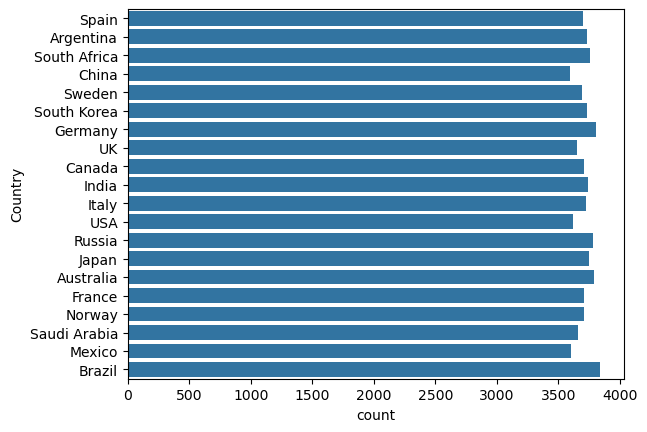

In [9]:
sns.countplot(data=df,y="Country")
plt.show()

# according to this country coloumn is not enough use for us

In [10]:
df.drop(columns=["Country"],inplace=True)

In [11]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'BMI', 'Physical Activity Level',
       'Smoking Status', 'Alcohol Consumption', 'Diabetes', 'Hypertension',
       'Cholesterol Level', 'Family History of Alzheimer’s',
       'Cognitive Test Score', 'Depression Level', 'Sleep Quality',
       'Dietary Habits', 'Air Pollution Exposure', 'Employment Status',
       'Marital Status', 'Genetic Risk Factor (APOE-ε4 allele)',
       'Social Engagement Level', 'Income Level', 'Stress Levels',
       'Urban vs Rural Living', 'Alzheimer Diagnosis'],
      dtype='object')

In [12]:
df.value_counts("Smoking Status")

Smoking Status
Current    24915
Never      24740
Former     24628
Name: count, dtype: int64

In [13]:
num_cols=df.dtypes[df.dtypes!="object"].index
num_cols

Index(['Age', 'Education Level', 'BMI', 'Cognitive Test Score'], dtype='object')

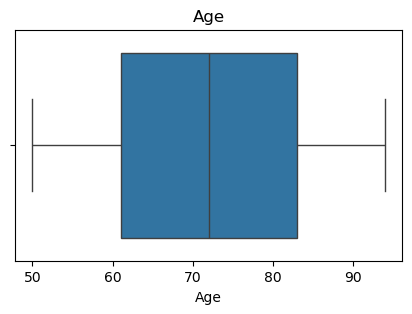

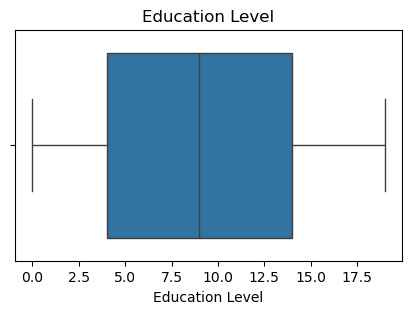

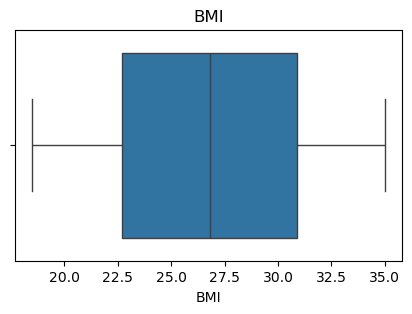

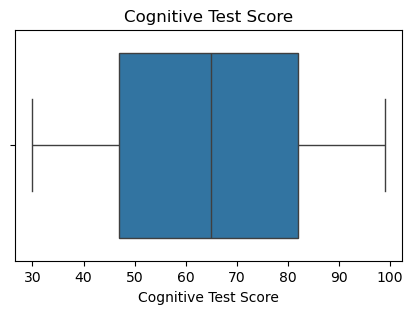

In [14]:
for i in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

# no outliers 

according to this data i have no outliers


In [15]:
cat_cols=df.dtypes[df.dtypes=="object"].index
cat_cols

Index(['Gender', 'Physical Activity Level', 'Smoking Status',
       'Alcohol Consumption', 'Diabetes', 'Hypertension', 'Cholesterol Level',
       'Family History of Alzheimer’s', 'Depression Level', 'Sleep Quality',
       'Dietary Habits', 'Air Pollution Exposure', 'Employment Status',
       'Marital Status', 'Genetic Risk Factor (APOE-ε4 allele)',
       'Social Engagement Level', 'Income Level', 'Stress Levels',
       'Urban vs Rural Living', 'Alzheimer Diagnosis'],
      dtype='object')

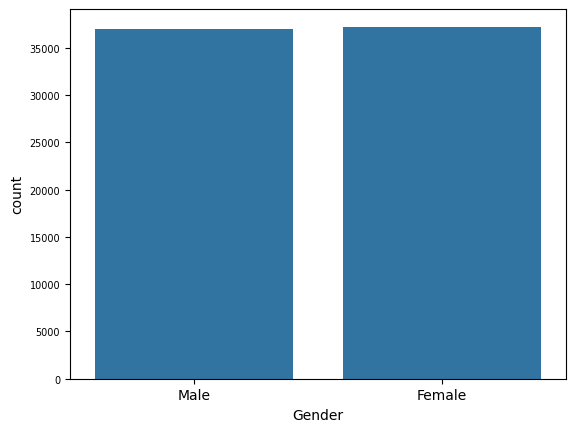

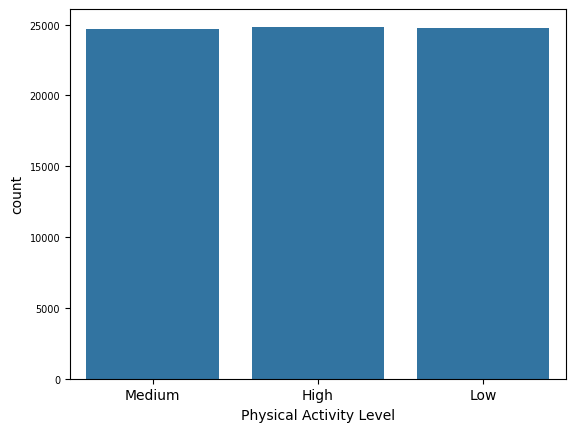

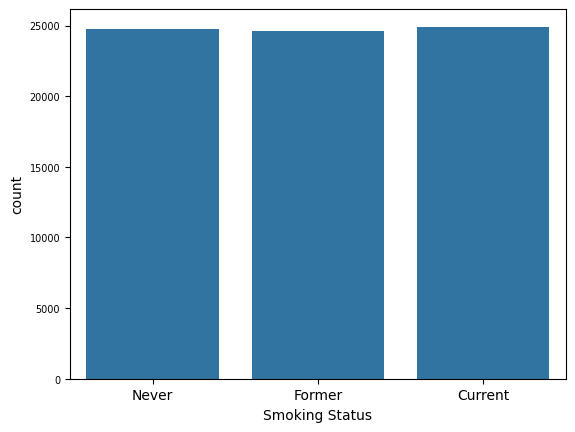

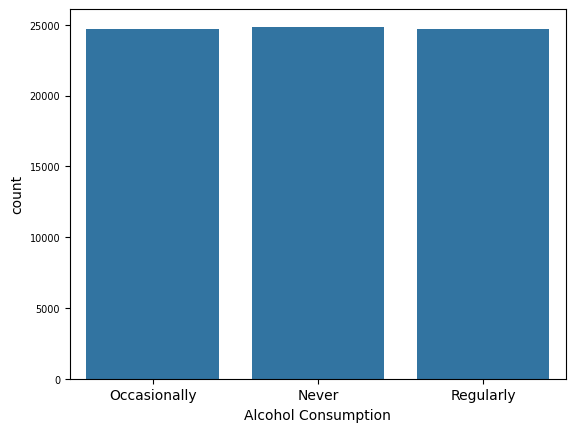

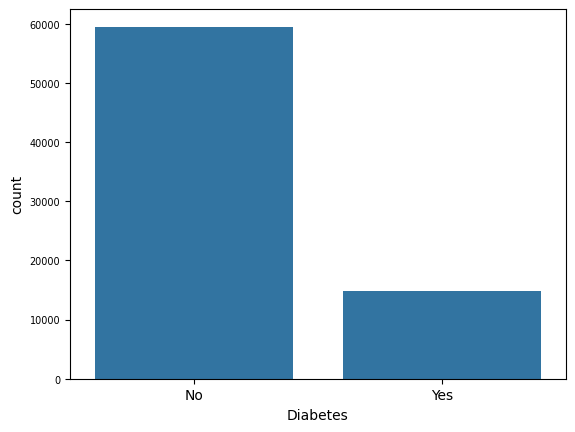

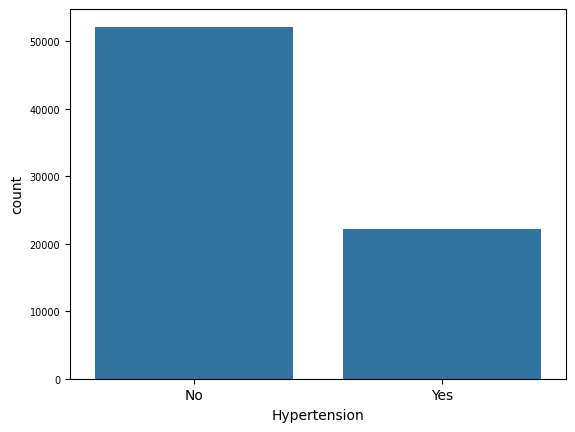

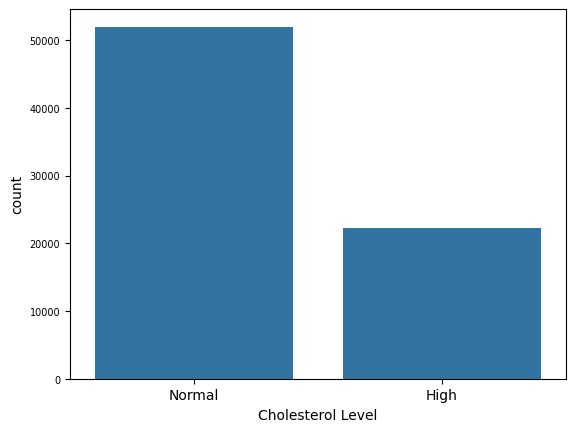

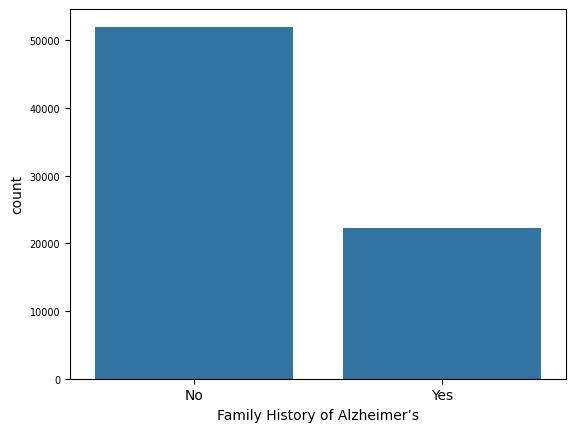

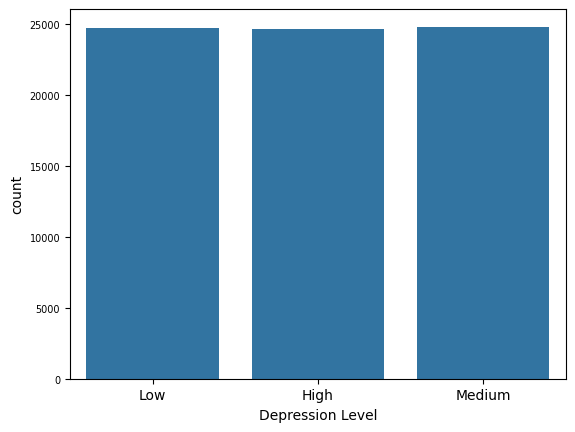

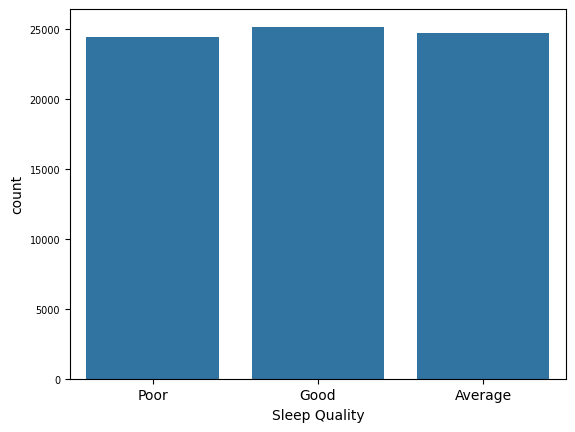

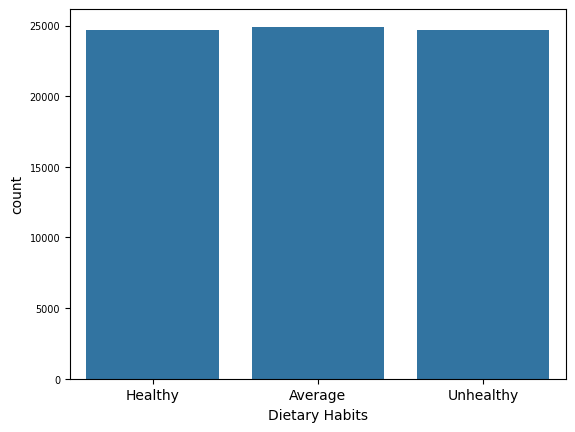

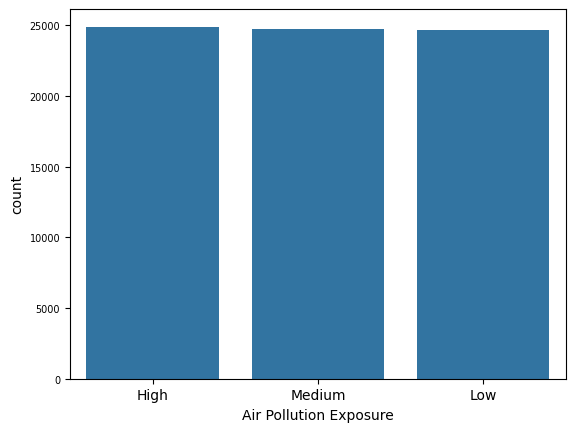

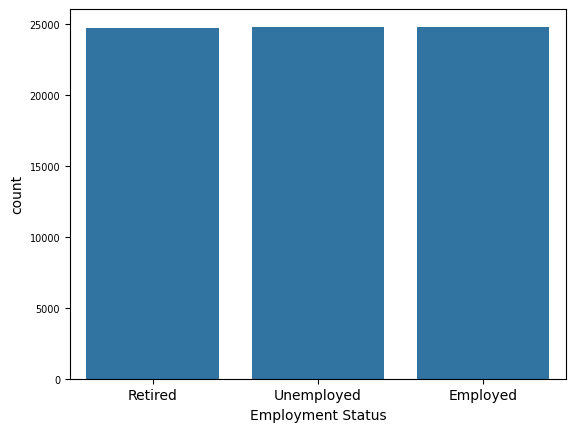

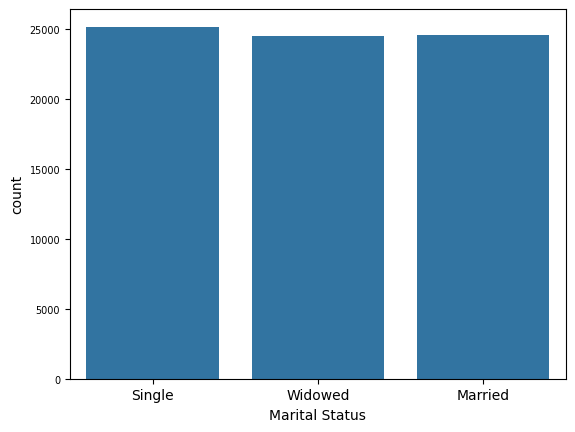

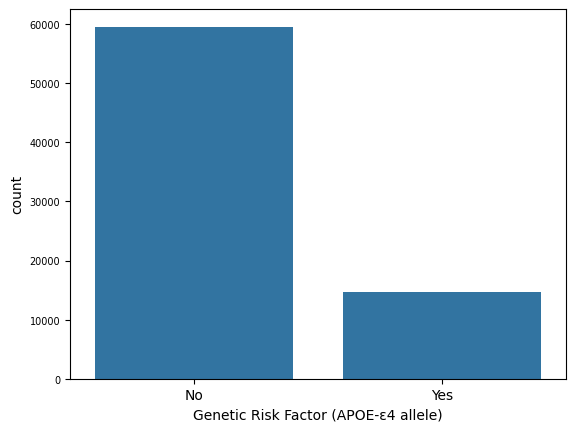

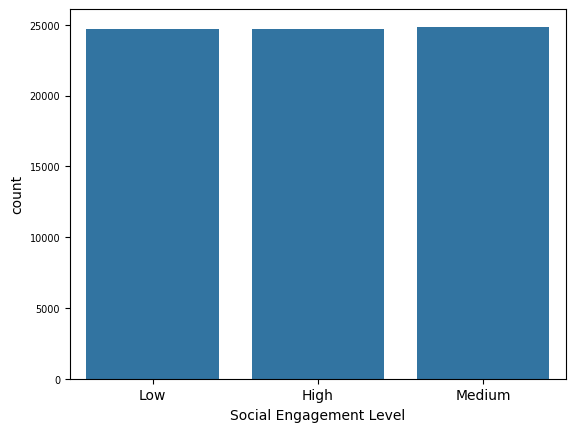

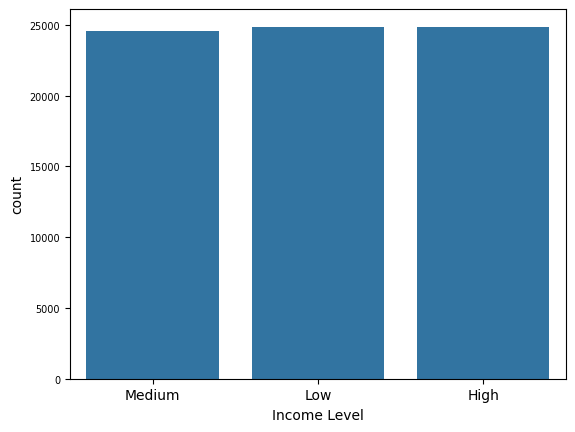

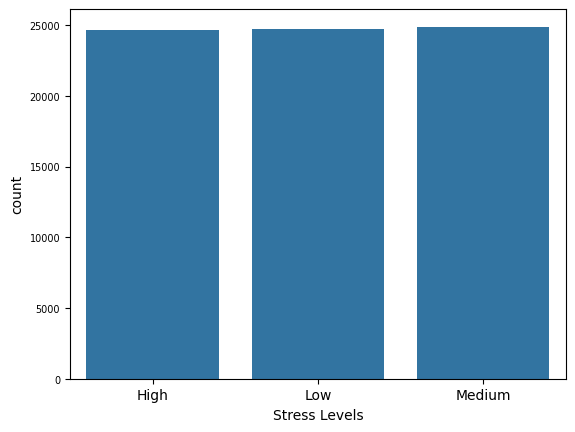

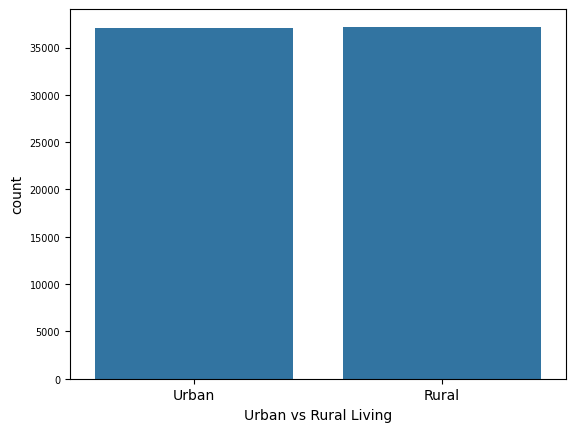

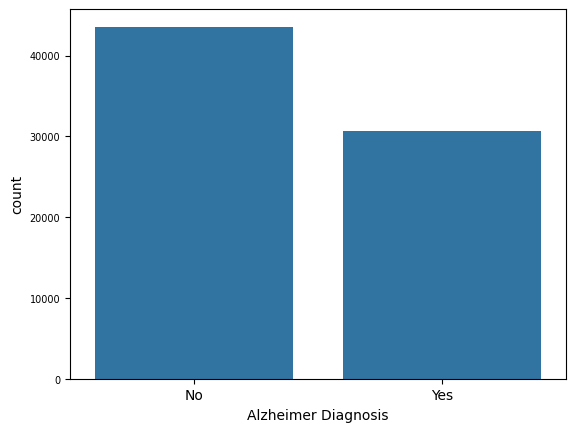

In [16]:
for i in cat_cols:
    sns.countplot(x=df[i])
    
    plt.yticks(fontsize=7)
    plt.show()

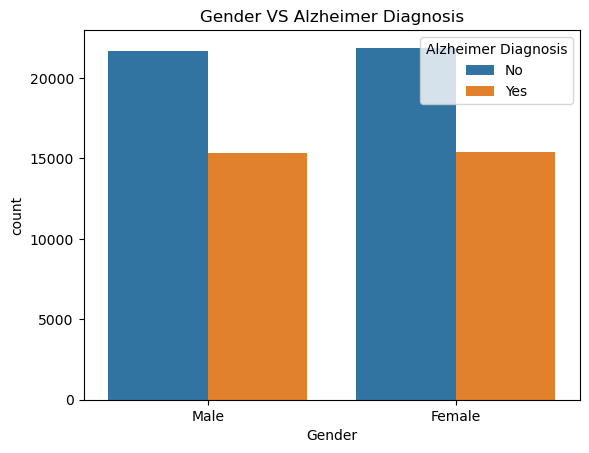

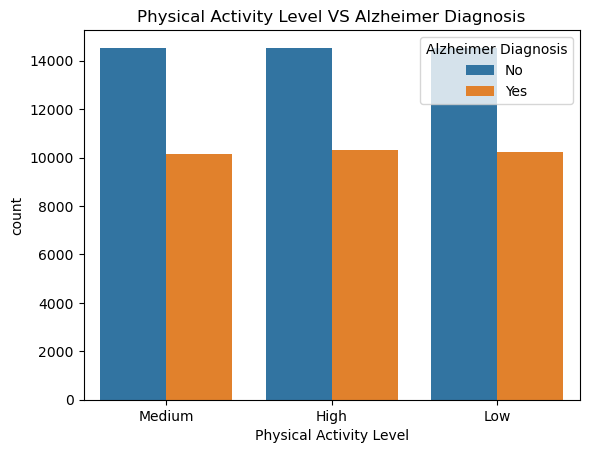

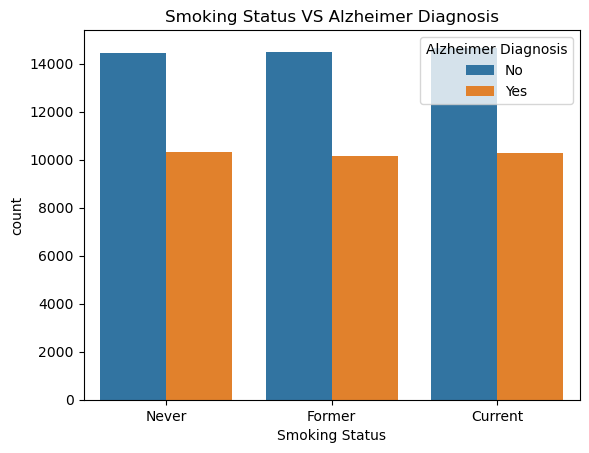

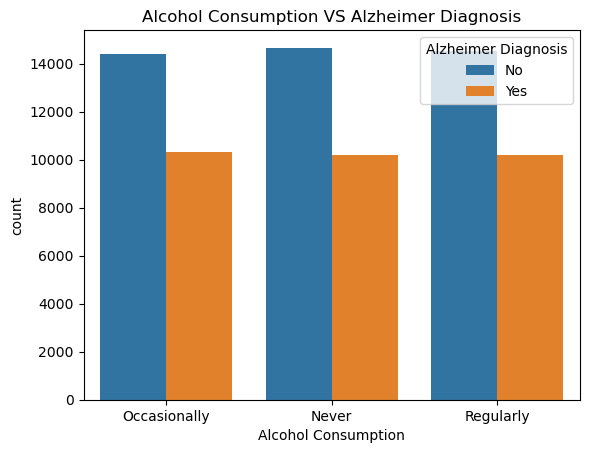

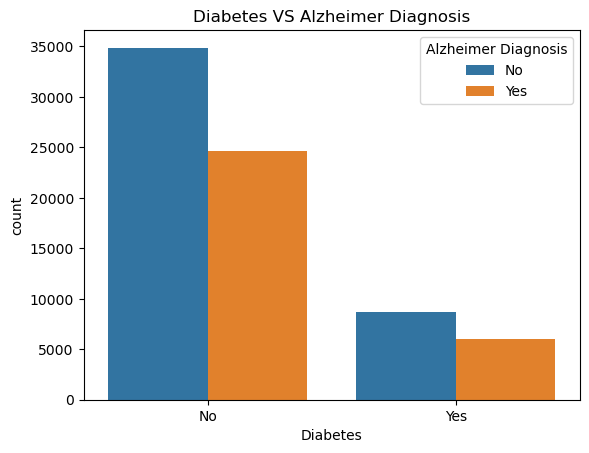

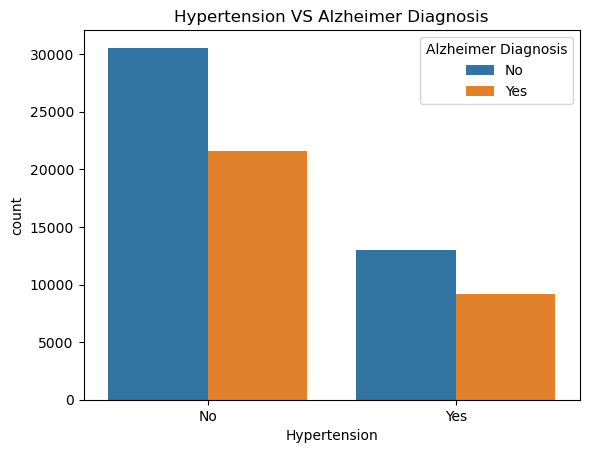

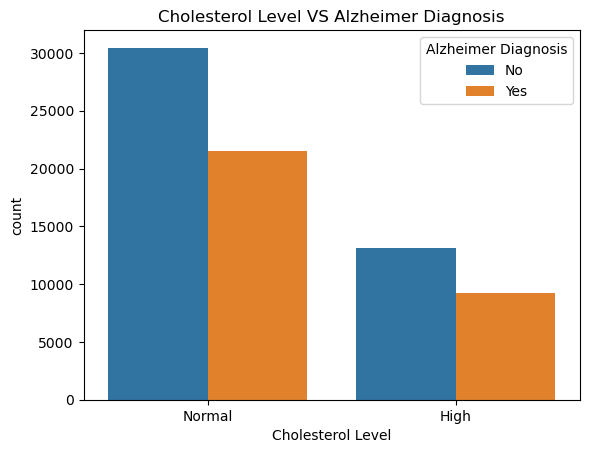

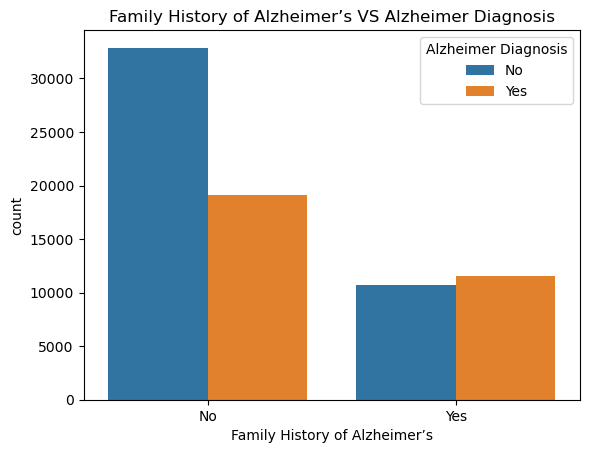

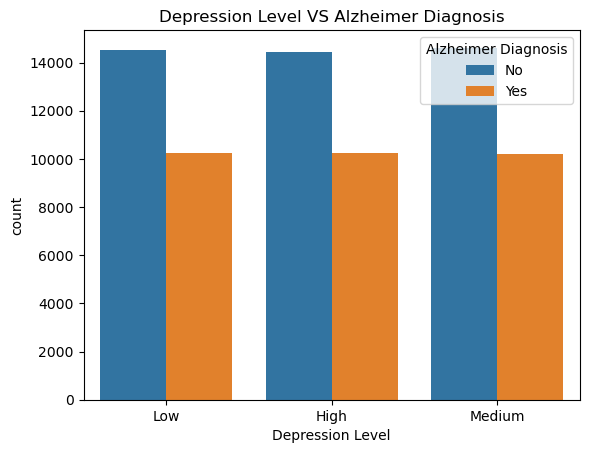

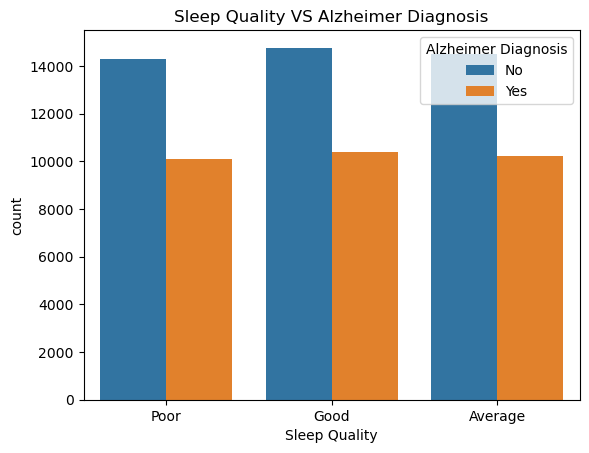

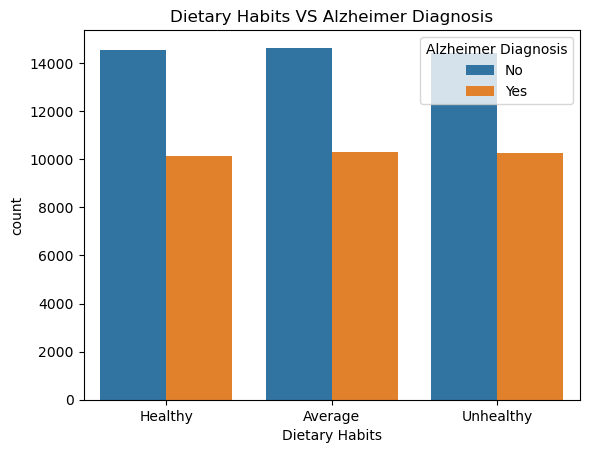

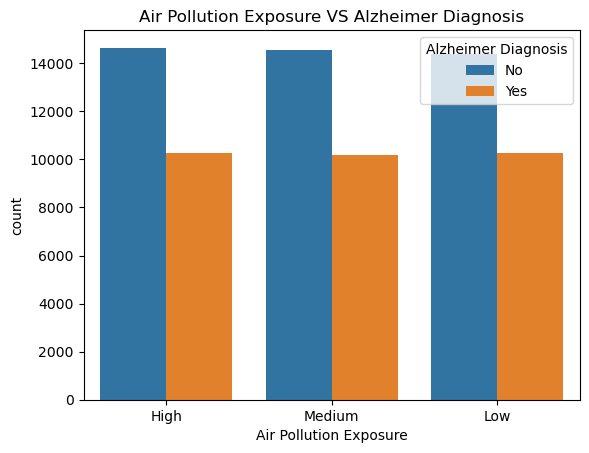

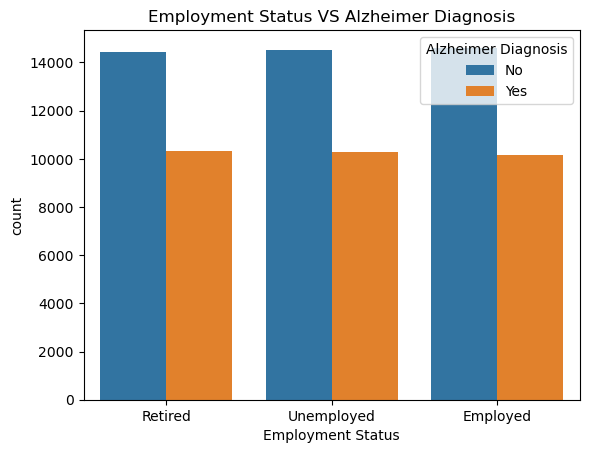

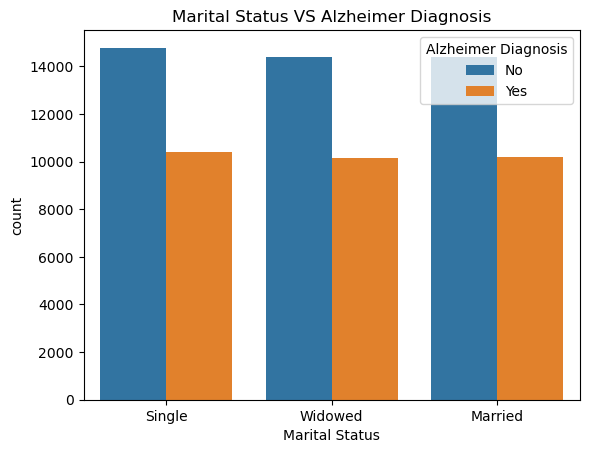

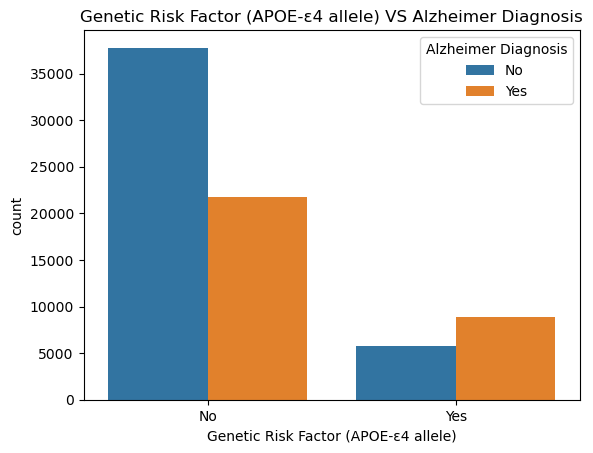

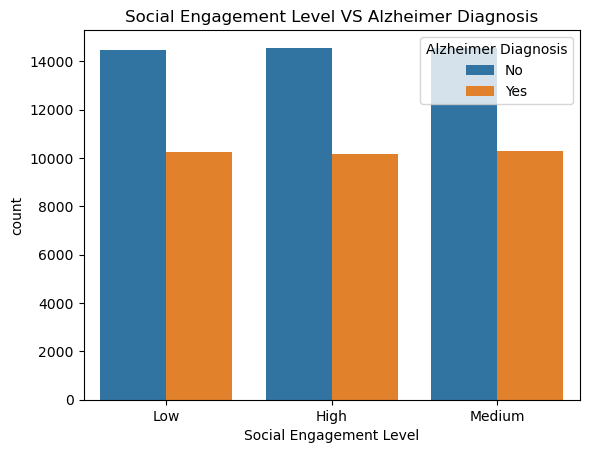

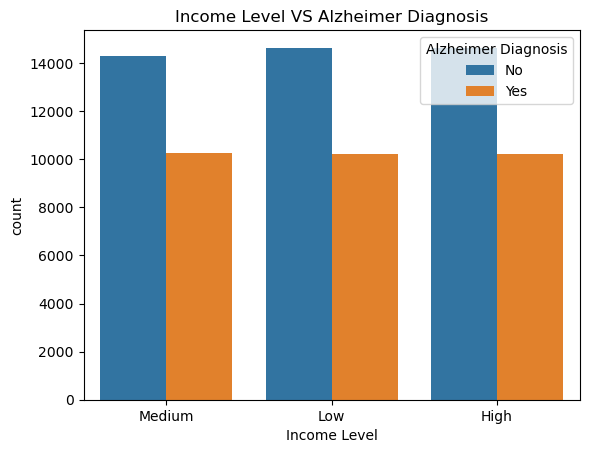

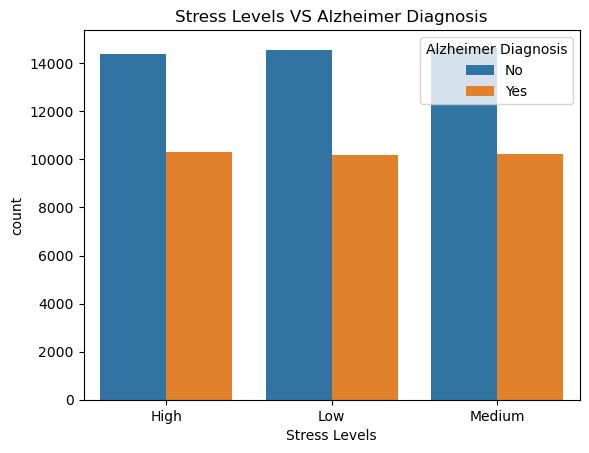

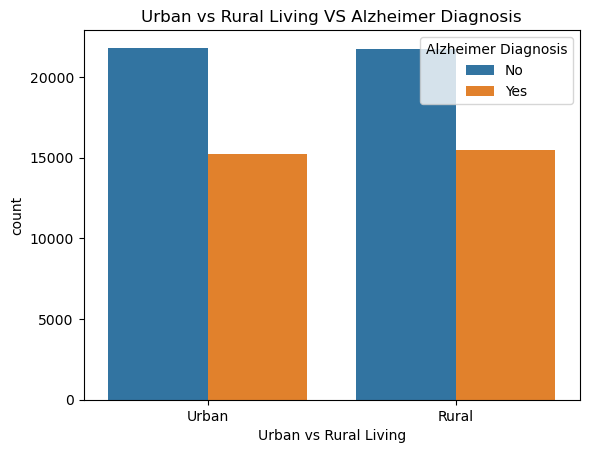

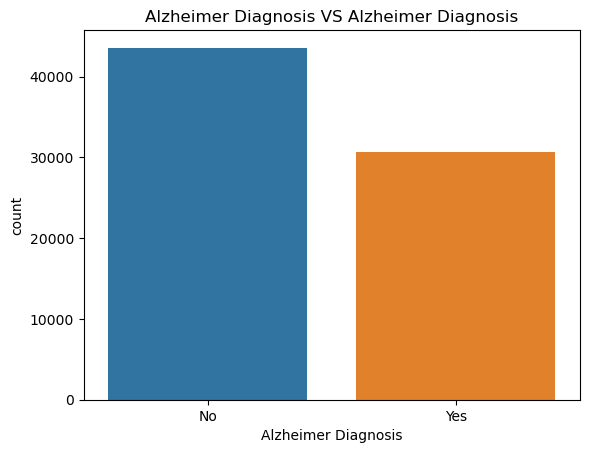

In [17]:
for i in cat_cols:
    sns.countplot(x=df[i],hue= "Alzheimer Diagnosis",data=df)
    plt.title(f"{i} VS Alzheimer Diagnosis")
    plt.show()

In [18]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'BMI', 'Physical Activity Level',
       'Smoking Status', 'Alcohol Consumption', 'Diabetes', 'Hypertension',
       'Cholesterol Level', 'Family History of Alzheimer’s',
       'Cognitive Test Score', 'Depression Level', 'Sleep Quality',
       'Dietary Habits', 'Air Pollution Exposure', 'Employment Status',
       'Marital Status', 'Genetic Risk Factor (APOE-ε4 allele)',
       'Social Engagement Level', 'Income Level', 'Stress Levels',
       'Urban vs Rural Living', 'Alzheimer Diagnosis'],
      dtype='object')

In [19]:
important_cols={'Diabetes','Hypertension','Cholesterol Level','Family History of Alzheimer’s',
             'Genetic Risk Factor (APOE-ε4 allele)','Alzheimer Diagnosis'}

In [20]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()


# Applying LabelEncoder to each column separately
for col in important_cols:
    df[col]=lb.fit_transform(df[col]) # Encode each column individually
    #why use of fit_transform
    
#Fit = learn
#Transform = apply
print(df.head())

   Age  Gender  Education Level   BMI Physical Activity Level Smoking Status  \
0   90    Male                1  33.0                  Medium          Never   
1   72    Male                7  29.9                  Medium         Former   
2   86  Female               19  22.9                    High        Current   
3   53    Male               17  31.2                     Low          Never   
4   58  Female                3  30.0                    High         Former   

  Alcohol Consumption  Diabetes  Hypertension  Cholesterol Level  ...  \
0        Occasionally         0             0                  1  ...   
1               Never         0             0                  1  ...   
2        Occasionally         0             1                  1  ...   
3           Regularly         1             0                  1  ...   
4               Never         1             0                  1  ...   

   Dietary Habits  Air Pollution Exposure Employment Status Marital Status  \
0 

In [21]:
df.drop(columns={'Gender', 'Physical Activity Level', 'Smoking Status',
       'Alcohol Consumption', 'Depression Level', 'Sleep Quality',
       'Dietary Habits', 'Air Pollution Exposure', 'Employment Status',
       'Marital Status','Social Engagement Level', 'Income Level', 'Stress Levels',
       'Urban vs Rural Living'},inplace=True)

In [22]:
df.head()

,Age,Education Level,BMI,Diabetes,Hypertension,Cholesterol Level,Family History of Alzheimer’s,Cognitive Test Score,Genetic Risk Factor (APOE-ε4 allele),Alzheimer Diagnosis
0,90,1,33.0,0,0,1,0,90,0,0
1,72,7,29.9,0,0,1,0,65,0,0
2,86,19,22.9,0,1,1,0,43,0,0
3,53,17,31.2,1,0,1,0,81,0,0
4,58,3,30.0,1,0,1,0,49,0,0


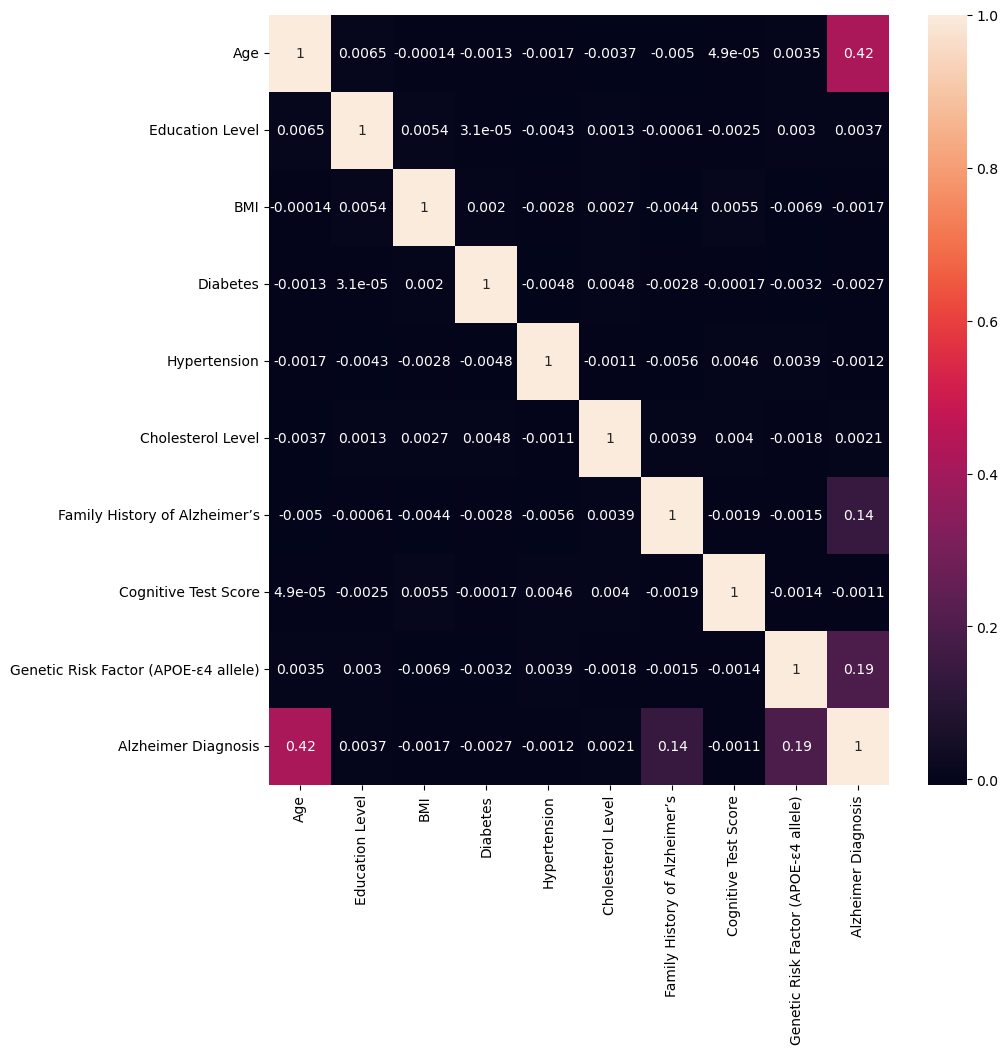

In [23]:
corr= df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)
plt.show()

In [24]:
x=df.drop("Alzheimer Diagnosis",axis=1)
y=df["Alzheimer Diagnosis"]
print(x.shape,y.shape)

(74283, 9) (74283,)


In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state= 33)

In [26]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(55712, 9) (18571, 9) (55712,) (18571,)


In [27]:
from sklearn.linear_model import LogisticRegression
m1=LogisticRegression()
m1.fit(x_train,y_train)

C:\Users\gurki\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
print('Training Score',m1.score(x_train,y_train))
print('Testing Score',m1.score(x_test,y_test))

Training Score 0.7112650775416427
Testing Score 0.7084163480695709


In [29]:
ypred_m1=m1.predict(x_test)
print(ypred_m1)

# “Use the learned model to predict output values for new inputs.”

[1 1 0 ... 0 0 0]


In [30]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
# why we use testing data and use predicted x test
cm_m1  = confusion_matrix(y_test,ypred_m1)
print(cm_m1)
print(classification_report(y_test,ypred_m1))

[[8551 2352]
 [3063 4605]]
              precision    recall  f1-score   support

           0       0.74      0.78      0.76     10903
           1       0.66      0.60      0.63      7668

    accuracy                           0.71     18571
   macro avg       0.70      0.69      0.69     18571
weighted avg       0.71      0.71      0.71     18571



# KNN

## standardizing Data

In [31]:
from sklearn.preprocessing import StandardScaler
# standardizing data
scaler=StandardScaler()
X_train=scaler.fit_transform(x_train) 
# we use fit_transform in xtrain beccause we want that our data comes into its original form
X_test=scaler.transform(x_test)


In [32]:
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor

In [33]:
# train knn model
k=21 # knn
knn=KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=21)

In [34]:
from sklearn.metrics import accuracy_score

# Predict on test data
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.704054708954822


In [35]:
# Accuracy on training data
y_train_pred = knn.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f'Training Accuracy: {train_accuracy:.2f}')

# Accuracy on test data
y_test_pred = knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Test Accuracy: {test_accuracy:.2f}')

Training Accuracy: 0.74
Test Accuracy: 0.70


In [36]:
from sklearn.metrics import confusion_matrix, classification_report

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", conf_matrix)

# Generate classification report
class_report = classification_report(y_test, y_test_pred)
print("\nClassification Report:\n", class_report)

Confusion Matrix:
 [[8326 2577]
 [2919 4749]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.76      0.75     10903
           1       0.65      0.62      0.63      7668

    accuracy                           0.70     18571
   macro avg       0.69      0.69      0.69     18571
weighted avg       0.70      0.70      0.70     18571



# Decision Tree

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV 
#GridSearchCV is used to automatically tune hyperparameters by trying all combinations 
#using cross-validation and selecting the best performing model.

In [46]:
params={'criterion': ['gini','entropy'], # by default it also pick gini
        'min_samples_split':[13,19,23,27], #Node with <13 samples → can split ✅
                                    # Node with 9 samples → cannot split ❌ (becomes leaf)
        'max_depth':[5,11,13,15]}
# these are the parameter

In [47]:
dt=DecisionTreeClassifier()
gs=GridSearchCV(dt,param_grid=params,scoring="accuracy",cv=5)
gs.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 11, 13, 15],
                         'min_samples_split': [13, 19, 23, 27]},
             scoring='accuracy')

In [51]:
gs.best_params_

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 27}

In [52]:
y_pred=gs.predict(x_test)

array([1, 1, 0, ..., 0, 0, 0])

In [57]:
print("training score: ",gs.score(x_train,y_train))
print("testing score:",gs.score(x_test,y_test))

training score:  0.7266477599080988
testing score: 0.7279091055947445


In [64]:
cm_gs  = confusion_matrix(y_test,y_pred)
print(cm_gs)
print(classification_report(y_test,y_pred))

[[7951 2952]
 [2150 5518]]
              precision    recall  f1-score   support

           0       0.79      0.73      0.76     10903
           1       0.65      0.72      0.68      7668

    accuracy                           0.73     18571
   macro avg       0.72      0.72      0.72     18571
weighted avg       0.73      0.73      0.73     18571



# if we don't you params we can use it like this without gridsearchcv

In [62]:
# if we don't you params we can use it like this without gridsearchcv
dt=DecisionTreeClassifier(min_samples_split=25,max_depth=6)
dt.fit(x_train, y_train)

# y_pred=dt.predict(x_test)
print("training",dt.score(x_train,y_train))
print("testing", dt.score(x_test,y_test))

training 0.7279760195290064
testing 0.7252705831673039


# Random Forst

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [70]:
parameters={'max_features': [2, 3, 5, 7], # max features are no. of independent variables
            'min_samples_split': [27],
            'max_depth': [5],
            #'bootstrap': [True, False]
           }


In [76]:
rf=RandomForestClassifier()
cv=GridSearchCV(rf,parameters)

In [78]:
cv.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5], 'max_features': [2, 3, 5, 7],
                         'min_samples_split': [27]})

In [79]:
cv.best_params_

{'max_depth': 5, 'max_features': 7, 'min_samples_split': 27}

In [80]:
print("training:", cv.score(x_train,y_train))
print("testing: ", cv.score(x_test,y_test))

training: 0.7267554566341183
testing:  0.7278014108017877


In [82]:
y_pred=cv.predict(x_test)

In [83]:
from sklearn.metrics import confusion_matrix, classification_report

In [88]:
cm=confusion_matrix(y_test,y_pred)
cm2=classification_report(y_test,y_pred)
print("confusion matrix:\n" ,cm)
print("classification_report: \n",cm2)

confusion matrix:
 [[7909 2994]
 [2061 5607]]
classification_report: 
               precision    recall  f1-score   support

           0       0.79      0.73      0.76     10903
           1       0.65      0.73      0.69      7668

    accuracy                           0.73     18571
   macro avg       0.72      0.73      0.72     18571
weighted avg       0.73      0.73      0.73     18571



In [91]:
from sklearn.svm import SVC

In [93]:
svm=SVC(kernel="rbf",C=1.4)
svm.fit(X_train,y_train)

SVC(C=1.4)

In [ ]:
svm.score(X_test,y_test)

In [ ]:
svm.score(X_train,y_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
y_pred=svm.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)

In [ ]:
print(cm)
print(cr)